

**Gold Badge Assignment-1**:
*Using ImageNet-pretrained ResNet for cat vs dog classification → just replace and train the last classification layer so that it can detect objects such as car, truck, bicycle and a pedestrian*



#===================================
ImageNet-pretrained ResNet → replace last layer → classify (car, truck, bicycle, person)
#===================================

=========================
#1. Install Dependencies
=========================

In [35]:
!pip install torch torchvision matplotlib pillow

=========================
# 2. Imports
=========================

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
from PIL import Image
import os

=========================
# 3. DATA PATH
=========================

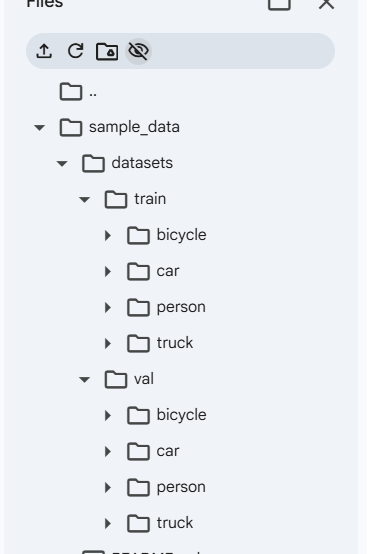

In [37]:
DATASET_PATH = "sample_data/datasets"   # change if needed
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")

=========================
# 3. Data Transforms
=========================

In [38]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [57]:
#Remove .ipynb_checkpoints
import shutil

checkpoint_path = "sample_data/datasets/.ipynb_checkpoints"
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)

checkpoint_path = "sample_data/datasets/train/.ipynb_checkpoints"
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)

checkpoint_path = "sample_data/datasets/val/.ipynb_checkpoints"
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)

print("Cleaned checkpoints!")

Cleaned checkpoints!


In [58]:
#Verify again Folder and its cocntents
for root, dirs, files in os.walk("sample_data/datasets"):
    print("DIR:", root)
    print("SUBDIRS:", dirs)
    print("FILES:", files[:3])  # sample
    print("-"*30)

DIR: sample_data/datasets
SUBDIRS: ['train', 'val']
FILES: []
------------------------------
DIR: sample_data/datasets/train
SUBDIRS: ['bicycle', 'person', 'car', 'truck']
FILES: []
------------------------------
DIR: sample_data/datasets/train/bicycle
SUBDIRS: []
FILES: ['bicycle.jpg', 'blue_bicycle.jpg']
------------------------------
DIR: sample_data/datasets/train/person
SUBDIRS: []
FILES: ['person_standing.jpg', 'person.jpg']
------------------------------
DIR: sample_data/datasets/train/car
SUBDIRS: []
FILES: ['white_car.jpg', 'yellow_car.jpg']
------------------------------
DIR: sample_data/datasets/train/truck
SUBDIRS: ['.ipynb_checkpoints']
FILES: ['truck1.jpg', 'truck.jpg']
------------------------------
DIR: sample_data/datasets/train/truck/.ipynb_checkpoints
SUBDIRS: []
FILES: []
------------------------------
DIR: sample_data/datasets/val
SUBDIRS: ['bicycle', 'person', 'car', 'truck']
FILES: []
------------------------------
DIR: sample_data/datasets/val/bicycle
SUBDIRS: [

=========================
# 4. Load Dataset
=========================

In [41]:
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['bicycle', 'car', 'person', 'truck']


====================================
# 5. Load Pretrained ResNet
====================================

In [42]:
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)

================================
# 6. Replace Final Layer
================================

In [43]:
num_classes = 4  # car, truck, bicycle, person

model.fc = nn.Linear(model.fc.in_features, num_classes)

======================================
# 7. Freeze Backbone/Transfer Learning
======================================

In [44]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True


=========================
# 8. Training Setup
=========================

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

=========================
# 9. Training Loop
=========================

In [46]:
num_epochs = 10 # increase for small dataset overfitting test

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 1.4250
Epoch [2/10], Loss: 1.2473
Epoch [3/10], Loss: 1.0829
Epoch [4/10], Loss: 0.9332
Epoch [5/10], Loss: 0.7990
Epoch [6/10], Loss: 0.6805
Epoch [7/10], Loss: 0.5773
Epoch [8/10], Loss: 0.4886
Epoch [9/10], Loss: 0.4131
Epoch [10/10], Loss: 0.3493


=========================
# 10. Validation
=========================

In [47]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 75.00%


=========================
# 11. Inference (Single Image)
=========================

In [55]:
def predict(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]

# Test
print(predict("sample_data/datasets/val/bicycle/red_bicycle.jpg"))
print(predict("sample_data/datasets/val/truck/cow.jpg"))
print(predict("sample_data/datasets/val/car/blue_car.jpg"))
print(predict("sample_data/datasets/val/truck/truck_test.jpg"))
print(predict("sample_data/datasets/val/person/person_walking.jpg"))
print(predict("sample_data/datasets/val/truck/cow.jpg"))




bicycle
bicycle
car
truck
person
bicycle


=========================
# 12. Save Model
=========================

In [56]:
torch.save(model.state_dict(), "resnet50_classifier.pth")
print("Model saved!")

Model saved!
